/cosma/local/Python/2.7.3/lib/python2.7/site-packages/matplotlib/__init__.py:913: UserWarning: savefig.extension is deprecated and replaced with savefig.format; please use the latter.
  warnings.warn(self.msg_depr % (key, alt_key))


Once deleted, variables cannot be recovered. Proceed (y/[n])? y
933678 964200


/cosma/local/Python/2.7.3/lib/python2.7/site-packages/matplotlib/font_manager.py:1297: UserWarning: findfont: Font family [u'cursive'] not found. Falling back to DejaVu Sans
  (prop.get_family(), self.defaultFamily[fontext]))


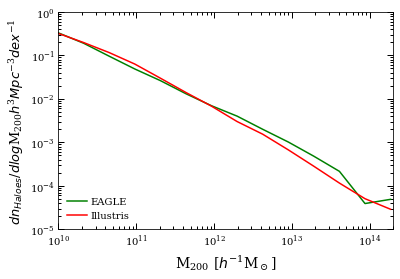

In [1]:
# Author: Lucas A. Bignone
# Contact: lbignone@iafe.uba.ar

# Plot simulation halo mass function and compare it with theorical results usgin HMFcalc
# ( http://hmf.icrar.org/ )
#

# from pygadget import Fof
%matplotlib inline
%reset

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
import h5py


def mass_function(mass, volume, n_bins):
    """ Calculate halo mass function

    Parameters:
        mass:   mass array in M_Sun / h
        volume: simulation volume in Mpc / h
        n_bins: numer of bins

    return mass, dn/dlogM
    """
    #bins = np.logspace(np.log10(mass.min()), np.log10(mass.max()), n_bins)
    bins = np.logspace(9.8, 14.4, n_bins)
    hist_result = np.histogram(mass, bins=bins)

    m = []
    dlogm = []
    for i in range(1, hist_result[1].size):
        m.append((hist_result[1][i] + hist_result[1][i-1])/2)
        dlogm.append(np.log10(hist_result[1][i]) - np.log10(hist_result[1][i-1]))

    dlogm = np.array(dlogm)
    V = volume
    dndlogm = hist_result[0]/(dlogm*V)

    return m, dndlogm


if __name__ == "__main__":
   
    plt.xlabel("M$_{200}$ [$h^{-1} $M$_\odot$]", fontsize=14)
    #plt.ylabel(r"Mass function $(\frac{dn}{dlogM})$ $h^3 Mpc^{-3}$", fontsize=13)
    plt.ylabel(r"$dn_{Haloes}/dlog$M$_{200} h^3 Mpc^{-3} dex^{-1}$", fontsize=13)
    plt.xlim(1e8, 1e15)
    plt.xscale("log")
    plt.yscale("log")
    plt.tick_params(which="both",direction='in', bottom="on", top="on", left="on", right="on")

    #grid()

    #show()
    
h=0.6777
volumes = (100.0 * h )**3
nb = 15

#EAGLE L100
#data = ascii.read("/home/celeste/Dropbox/EAGLE-M200-Mgroup-z0.1-Mgroupgt1e8.dat", data_start=1, delimiter=',')
#Mh_E = data["Group_M_Crit200"] * h
#Tot_gal = len(Mh_E) #Total of galaxies in the sample
#m2, dndlogm2 = mass_function(Mh_E, volumes, nb)
#plot(m2, dndlogm2, label="EAGLE- L0100N1504", linestyle="-", color="green")
data3 = ascii.read("/cosma/home/cartale/AssemblyBias/Environment/EAGLE-haloes-3.dat", data_start=1) #Con corte en la masa del halo
Mh_E = data3["Group_M_Crit200"] *h # Msun/h
m2, dndlogm2 = mass_function(Mh_E, volumes, nb)
plt.plot(m2, dndlogm2, label="EAGLE", linestyle="-", color="green")


h = 0.704
volumes = (106.5 * h)**3
f = h5py.File('Illustris/groups_135.0.hdf5','r')
halo_mass1 = f['Group']['Group_M_Crit200'] 
N = len(halo_mass1)
halo_mass_i = np.zeros(N)

#for i in range (0, N):
halo_mass_i[:] = halo_mass1[:] *10**(10)# Msun h^-1
idx = np.where(halo_mass_i >= 1e5)
print len(halo_mass_i[idx]), len(halo_mass_i)

mi, dndlogmi = mass_function(halo_mass_i[idx], volumes, nb)
plt.plot(mi, dndlogmi, label="Illustris", linestyle="-", color="red")


#data = ascii.read("/cosma/home/cartale/AssemblyBias/Environment/Illustris-halos-v2.dat", data_start=1, delimiter='\s') #Cambie tabla usando ahora un corte de 10^8.5 Msun
#Mhalo2 = data["M200"] # Msun/h
#mi, dndlogmi = mass_function(Mhalo2, volumes, nb)
#plt.plot(mi, dndlogmi, label="Illustris", linestyle=":", color="red")


plt.axis([1e10,2e14,1e-5,1])


plt.legend(loc=3, frameon=False)

figure2 = plt.gcf() #acá te quedarias con la referencia a la figura.
plt.show()
figure2.savefig("HMF-calc-M200.eps", bbox_inches='tight')  #guardas.

In [1]:
%matplotlib inline
%reset

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
import h5py

h = 0.704
volumes = (106.5 * h)**3
f = h5py.File('Illustris/groups_135.0.hdf5','r')
halo_mass1 = f['Group']['Group_M_Crit200']

halo_mass1 = np.asarray(halo_mass1)*10**10
aux = np.where(halo_mass1 > 10**10)
print "total Illustris halos", len(halo_mass1[aux])

/cosma/local/Python/2.7.3/lib/python2.7/site-packages/matplotlib/__init__.py:913: UserWarning: savefig.extension is deprecated and replaced with savefig.format; please use the latter.
  warnings.warn(self.msg_depr % (key, alt_key))


Once deleted, variables cannot be recovered. Proceed (y/[n])? y
total Illustris halos 74843
